# 📊 Case Ambev — Long Neck NENO — Gráficos
Visualizações para suporte à argumentação do case.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Constantes ────────────────────────────────────────────────────────────────
semanas  = ['W0\n02/fev', 'W1\n09/fev', 'W2\n16/fev', 'W3\n23/fev']
DOI_MIN  = 12
CAP_AQ   = 12600
CAP_NS   = 27000
BIAS     = 1.09
AVARIA   = 0.95

# ── PCP Malzbier ──────────────────────────────────────────────────────────────
prod_aq  = [0,     9000,  7560,  0    ]
prod_ns  = [16200, 0,     12960, 0    ]
prod_pcp = [a + b for a, b in zip(prod_aq, prod_ns)]
folgas   = [360,   9000,  0,     0    ]
prod_com_folga = [p + f for p, f in zip(prod_pcp, folgas)]

# ── Demanda Malzbier por GEO ──────────────────────────────────────────────────
malzbier = pd.DataFrame({
    'geo':   ['Mapapi', 'NE Norte', 'NE Sul', 'NO Araguaia', 'NO Centro'],
    'ei_w0': [1985.6,   302.0,      4383.0,   0.0,           964.8     ],
    'W0':    [6074.8,   1971.8,     3230.3,   78.9,          2227.5    ],
    'W1':    [6286.4,   2265.8,     3517.6,   92.9,          2463.1    ],
    'W2':    [4258.0,   1707.9,     2589.1,   62.9,          1789.6    ],
    'W3':    [5204.6,   1844.0,     2857.3,   65.9,          2025.9    ],
})
dem_raw         = [malzbier[s].sum() for s in ['W0','W1','W2','W3']]
dem_semana_bias = [d / BIAS for d in dem_raw]
ei_total        = malzbier['ei_w0'].sum()

# ── Balanço semana a semana — DOI PROSPECTIVO ────────────────────────────────
def calc_balanco(usar_folga):
    rows, estoque = [], ei_total
    for i in range(4):
        prod     = prod_pcp[i] + (folgas[i] if usar_folga else 0)
        dem      = dem_semana_bias[i]
        dem_prox = dem_semana_bias[i+1] if i < 3 else dem_semana_bias[i]
        ef       = estoque + prod - dem
        doi      = ef / dem_prox * 6  # DOI prospectivo
        rows.append({'EI': estoque, 'prod': prod, 'dem': dem, 'EF': ef, 'DOI': doi})
        estoque = ef
    return rows

bal_sem_folga = calc_balanco(False)
bal_com_folga = calc_balanco(True)

# ── Volume de transferência — DOI PROSPECTIVO ────────────────────────────────
estoque, transf_list, ef_list = ei_total, [], []
for i in range(4):
    prod     = prod_pcp[i] + folgas[i]
    dem      = dem_semana_bias[i]
    dem_prox = dem_semana_bias[i+1] if i < 3 else dem_semana_bias[i]
    ef_st    = estoque + prod - dem
    ef_min   = DOI_MIN * dem_prox / 6
    transf   = max(0, ef_min - ef_st)
    ef_final = ef_st + transf
    transf_list.append(transf / AVARIA)
    ef_list.append(ef_final)
    estoque = ef_final

total_transf = sum(transf_list)  # 15.898 HL

# ── Custos (valores reais do Excel) ──────────────────────────────────────────
cabo_ba    = 84.58
cabo_pb    = 95.33
rodo_ba    = cabo_ba * 1.6
rodo_pb    = cabo_pb * 1.6
cabo_medio = (cabo_ba + cabo_pb) / 2
rodo_medio = (rodo_ba + rodo_pb) / 2
maco       = 285

# ── Ocupação das linhas por semana ────────────────────────────────────────────
pcp_aq_total = [12240, 10800, 12600, 12600]
pcp_ns_total = [27000, 19800, 27000, 27000]

print('✅ Dados carregados')
print(f'   Total embarque SP→NE: {total_transf:,.0f} HL')
print(f'   Custo rodo total:     R$ {total_transf * rodo_medio:,.0f}')
print(f'   MACO rodo:            R$ {maco - rodo_medio:.2f}/HL')
print(f'   DOIs c/ folgas (prosp): W0={bal_com_folga[0]["DOI"]:.1f}d  W1={bal_com_folga[1]["DOI"]:.1f}d  W2={bal_com_folga[2]["DOI"]:.1f}d  W3={bal_com_folga[3]["DOI"]:.1f}d')

✅ Dados carregados
   Total embarque SP→NE: 15,898 HL
   Custo rodo total:     R$ 2,288,103
   MACO rodo:            R$ 141.07/HL
   DOIs c/ folgas (prosp): W0=5.2d  W1=10.3d  W2=14.9d  W3=8.9d


## Gráfico 1 — DOI Semana a Semana: Sem Folgas vs Com Folgas
> **Argumento:** As folgas de produção ajudam mas não são suficientes para atingir 12d em todas as semanas.

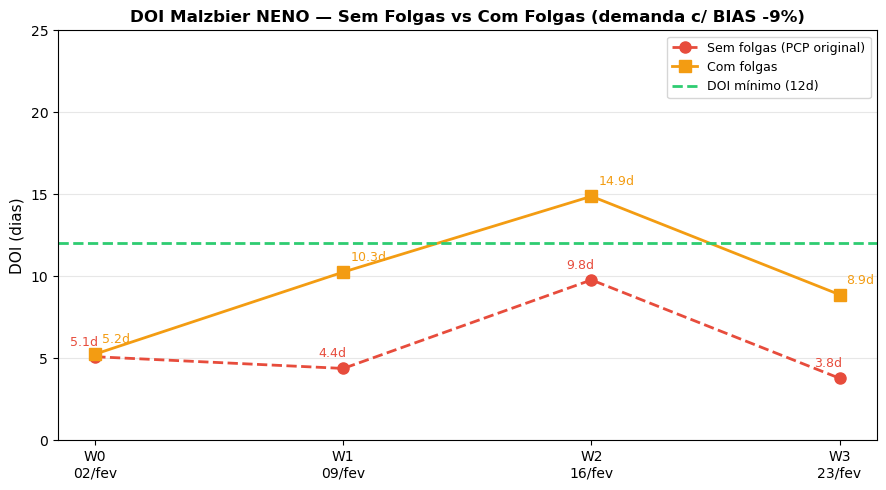

W3 é a semana crítica: zero produção + zero folga disponíveis nas linhas do NENO.


In [2]:
doi_sf = [r['DOI'] for r in bal_sem_folga]
doi_cf = [r['DOI'] for r in bal_com_folga]

x = np.arange(4)
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, doi_sf, 'o--', color='#e74c3c', linewidth=2, markersize=8, label='Sem folgas (PCP original)')
ax.plot(x, doi_cf, 's-',  color='#f39c12', linewidth=2, markersize=8, label='Com folgas')
ax.axhline(DOI_MIN, color='#2ecc71', linewidth=2, linestyle='--', label=f'DOI mínimo ({DOI_MIN}d)')

for i, (sf, cf) in enumerate(zip(doi_sf, doi_cf)):
    ax.annotate(f'{sf:.1f}d', (i, sf), textcoords='offset points', xytext=(-18, 8), fontsize=9, color='#e74c3c')
    ax.annotate(f'{cf:.1f}d', (i, cf), textcoords='offset points', xytext=(5,  8), fontsize=9, color='#f39c12')


ax.set_xticks(x); ax.set_xticklabels(semanas)
ax.set_ylabel('DOI (dias)', fontsize=11)
ax.set_title('DOI Malzbier NENO — Sem Folgas vs Com Folgas (demanda c/ BIAS -9%)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 25); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('W3 é a semana crítica: zero produção + zero folga disponíveis nas linhas do NENO.')

## Gráfico 2 — Demanda vs Capacidade de Produção de Malzbier
> **Argumento:** A produção local, mesmo com folgas, não cobre a demanda em todas as semanas.

NameError: name 'dem_semana' is not defined

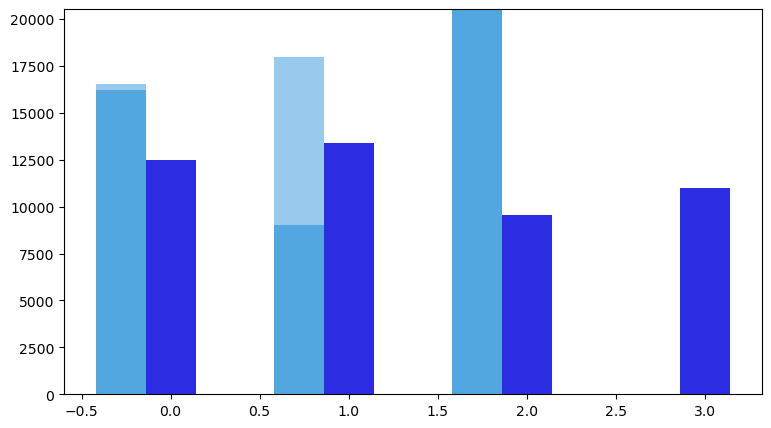

In [3]:
x = np.arange(4)
w = 0.28
fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - w,   prod_pcp,        w, label='Produção PCP',          color='#3498db', alpha=0.85)
b2 = ax.bar(x - w,   folgas,          w, label='+ Folga disponível',     color='#85c1e9', alpha=0.85,
            bottom=prod_pcp)
b3 = ax.bar(x,       dem_semana_bias, w, label='Demanda c/ BIAS (-9%)',  color="#0707de", alpha=0.85)
b4 = ax.bar(x + w,   dem_semana,      w, label='Demanda original (+30%)',color="#5e62db", alpha=0.5)

ax.set_xticks(x); ax.set_xticklabels(semanas)
ax.set_ylabel('Volume (HL)', fontsize=11)
ax.set_title('Demanda vs Produção Malzbier NENO', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

for i in range(4):
    tot = prod_pcp[i] + folgas[i]
    gap = dem_semana_bias[i] - tot
    if gap > 0:
        ax.annotate(f'Gap\n{gap:,.0f} hl', xy=(i, dem_semana_bias[i]),
                    xytext=(i + 0.05, dem_semana_bias[i] + 500),
                    fontsize=8, color='#e74c3c', fontweight='bold')

plt.tight_layout(); plt.show()

## Gráfico 3 — Ocupação das Linhas de Produção NENO
> **Argumento:** As linhas AQ541 e NS541 operam no limite — pouca margem para absorver crescimento futuro.

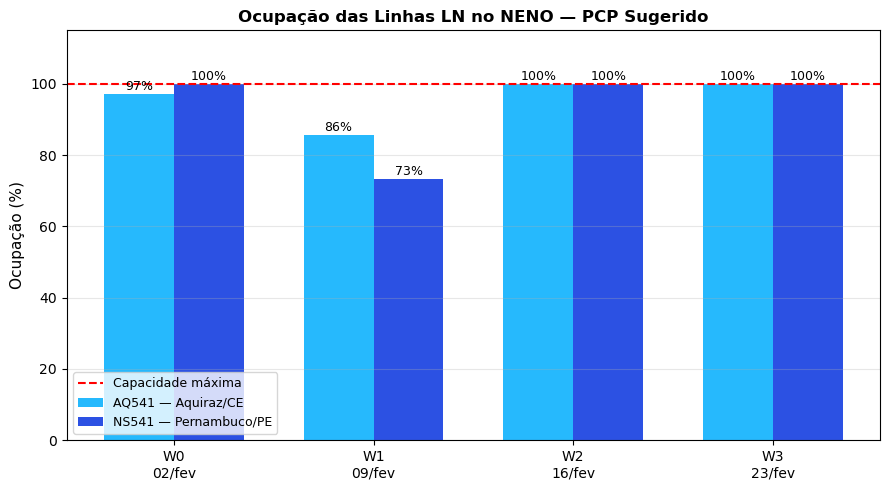

W1 é a única semana com folga relevante (NS541 a 73%). W2 e W3: ambas a 100%.


In [ ]:
x = np.arange(4)
w = 0.35
ocup_aq = [v / CAP_AQ * 100 for v in pcp_aq_total]
ocup_ns = [v / CAP_NS * 100 for v in pcp_ns_total]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, ocup_aq, w, label='AQ541 — Aquiraz/CE',    color="#00adfd", alpha=0.85)
ax.bar(x + w/2, ocup_ns, w, label='NS541 — Pernambuco/PE', color="#0732df", alpha=0.85)
ax.axhline(100, color='red', linewidth=1.5, linestyle='--', label='Capacidade máxima')

for i in range(4):
    ax.text(i - w/2, ocup_aq[i] + 1, f'{ocup_aq[i]:.0f}%', ha='center', fontsize=9)
    ax.text(i + w/2, ocup_ns[i] + 1, f'{ocup_ns[i]:.0f}%', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(semanas)
ax.set_ylabel('Ocupação (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.set_title('Ocupação das Linhas LN no NENO — PCP Sugerido', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('W1 é a única semana com folga relevante (NS541 a 73%). W2 e W3: ambas a 100%.')

## Gráfico 4 — Estoque Inicial por GEO
> **Argumento:** NE Norte inicia com estoque crítico — ruptura iminente já na W0.

/var/folders/_2/zyhx05bn6v9_vm62gkhxhr800000gn/T/ipykernel_10968/3712815600.py:32: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


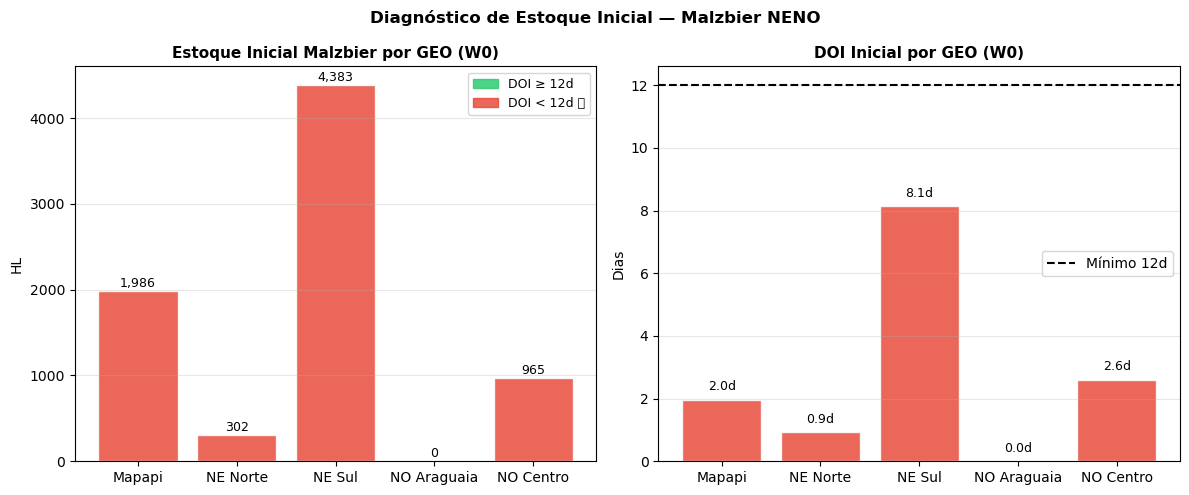

NE Norte: EI = 302 HL → DOI < 1 dia. Risco de ruptura já na W0!


In [ ]:
geos  = malzbier['geo'].tolist()
ei    = malzbier['ei_w0'].tolist()
dem_d = [malzbier['W0'][i] / 6 for i in range(5)]  # demanda diária W0
doi_geo = [e / d for e, d in zip(ei, dem_d)]

cores = ['#e74c3c' if d < DOI_MIN else '#2ecc71' for d in doi_geo]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Estoque inicial
bars = ax1.bar(geos, ei, color=cores, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, ei):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{v:,.0f}', ha='center', fontsize=9)
ax1.set_title('Estoque Inicial Malzbier por GEO (W0)', fontsize=11, fontweight='bold')
ax1.set_ylabel('HL'); ax1.grid(axis='y', alpha=0.3)

# DOI inicial
bars2 = ax2.bar(geos, doi_geo, color=cores, alpha=0.85, edgecolor='white')
ax2.axhline(DOI_MIN, color='black', linewidth=1.5, linestyle='--', label=f'Mínimo {DOI_MIN}d')
for bar, v in zip(bars2, doi_geo):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}d', ha='center', fontsize=9)
ax2.set_title('DOI Inicial por GEO (W0)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Dias'); ax2.legend(); ax2.grid(axis='y', alpha=0.3)

verde = mpatches.Patch(color='#2ecc71', alpha=0.85, label='DOI ≥ 12d')
verm  = mpatches.Patch(color='#e74c3c', alpha=0.85, label='DOI < 12d 🚨')
ax1.legend(handles=[verde, verm], fontsize=9)

plt.suptitle('Diagnóstico de Estoque Inicial — Malzbier NENO', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('NE Norte: EI = 302 HL → DOI < 1 dia. Risco de ruptura já na W0!')

## Gráfico 5 — MACO Líquido por Cenário de Abastecimento
> **Argumento:** Rodo corrói quase 50% da margem, mas mantém MACO positivo — vale para evitar ruptura.

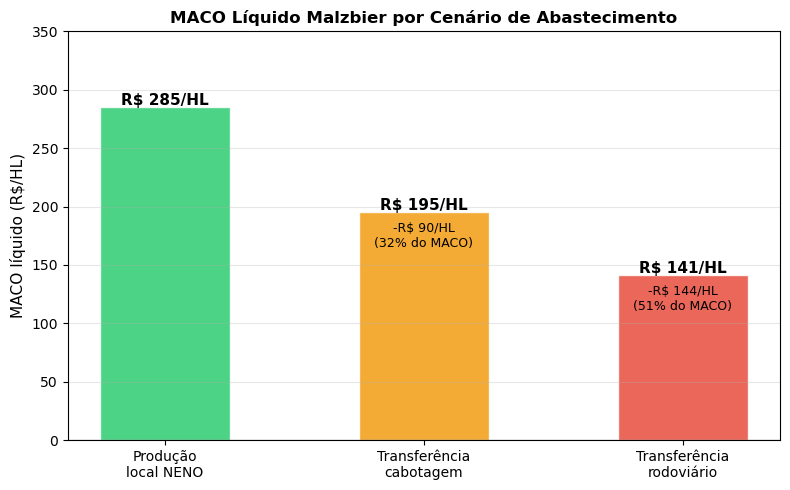

In [ ]:
cenarios = ['Produção\nlocal NENO', 'Transferência\ncabotagem', 'Transferência\nrodoviário']
macos    = [maco, maco - cabo_medio, maco - rodo_medio]
cores    = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cenarios, macos, color=cores, alpha=0.85, edgecolor='white', width=0.5)

for bar, v in zip(bars, macos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'R$ {v:.0f}/HL', ha='center', fontsize=11, fontweight='bold')

ax.text(1, macos[1] - 30, f'-R$ {maco - macos[1]:.0f}/HL\n({(maco-macos[1])/maco*100:.0f}% do MACO)',
        ha='center', fontsize=9, color="#000000")
ax.text(2, macos[2] - 30, f'-R$ {maco - macos[2]:.0f}/HL\n({(maco-macos[2])/maco*100:.0f}% do MACO)',
        ha='center', fontsize=9, color="#000000")

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('MACO líquido (R$/HL)', fontsize=11)
ax.set_title('MACO Líquido Malzbier por Cenário de Abastecimento', fontsize=12, fontweight='bold')
ax.set_ylim(0, 350); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Gráfico 6 — Volume de Transferência e Evolução do Estoque com Transferência
> **Argumento:** Volume de embarque necessário por semana e evolução do estoque garantindo DOI ≥ 12d.

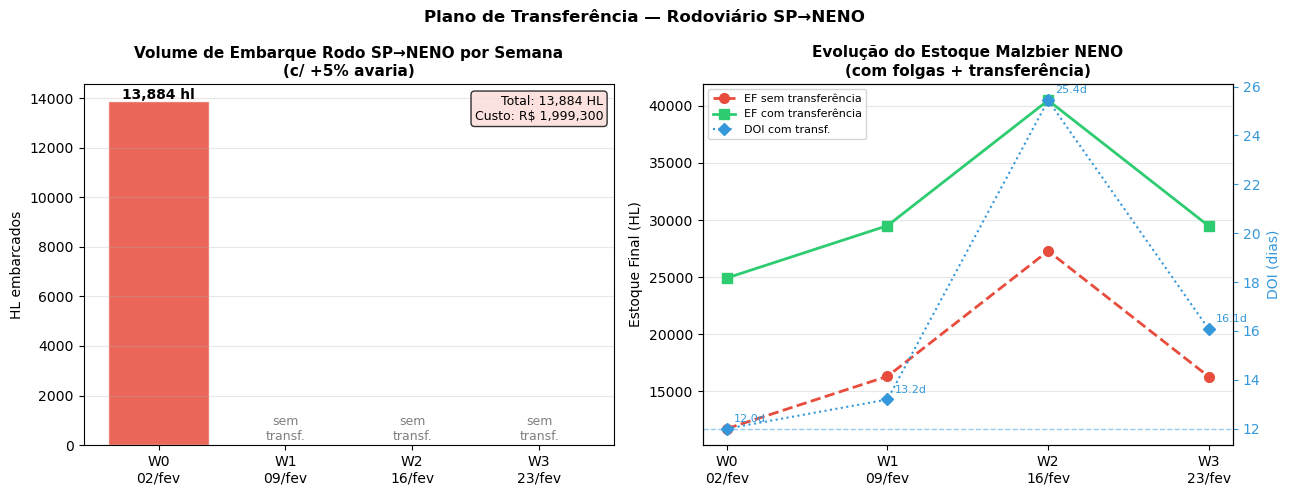

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Volume de embarque por semana
cores_t = ['#e74c3c' if t > 0 else '#95a5a6' for t in transf_list]
bars = ax1.bar(semanas, transf_list, color=cores_t, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, transf_list):
    if v > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{v:,.0f} hl', ha='center', fontsize=10, fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, 200, 'sem\ntransf.', ha='center', fontsize=9, color='gray')
ax1.set_title('Volume de Embarque Rodo SP→NENO por Semana\n(c/ +5% avaria)', fontsize=11, fontweight='bold')
ax1.set_ylabel('HL embarcados'); ax1.grid(axis='y', alpha=0.3)
ax1.text(0.98, 0.97, f'Total: {sum(transf_list):,.0f} HL\nCusto: R$ {sum(transf_list)*rodo_medio:,.0f}',
         transform=ax1.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#fadbd8', alpha=0.8))

# Evolução do estoque
dem_prox_list   = dem_semana_bias[1:] + [dem_semana_bias[-1]]  # DOI prospectivo
doi_com_transf  = [ef / dp * 6 for ef, dp in zip(ef_list, dem_prox_list)]
ef_sem_transf_list = [r['EF'] for r in bal_com_folga]

ax2.plot(semanas, ef_sem_transf_list, 'o--', color='#e74c3c', linewidth=2, markersize=7,
         label='EF sem transferência')
ax2.plot(semanas, ef_list,            's-',  color='#2ecc71', linewidth=2, markersize=7,
         label='EF com transferência')

ax2b = ax2.twinx()
ax2b.plot(semanas, doi_com_transf, 'D:', color='#3498db', linewidth=1.5, markersize=6,
          label='DOI com transf.')
ax2b.axhline(DOI_MIN, color='#3498db', linewidth=1, linestyle='--', alpha=0.5)
ax2b.set_ylabel('DOI (dias)', color='#3498db')
ax2b.tick_params(axis='y', colors='#3498db')
for i, d in enumerate(doi_com_transf):
    ax2b.annotate(f'{d:.1f}d', (semanas[i], d), textcoords='offset points',
                  xytext=(5, 5), fontsize=8, color='#3498db')

ax2.set_title('Evolução do Estoque Malzbier NENO\n(com folgas + transferência)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Estoque Final (HL)')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Plano de Transferência — Rodoviário SP→NENO', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()